# Contextualização do Problema

## Definição do Problema

Este trabalho tem como objetivo identificar a presença de **câncer** em pacientes utilizando técnicas de *machine learning supervisionado*.

Os principais pontos abordados são:

- Análise exploratória dos dados
- Pré-processamento e limpeza
- Treinamento de múltiplos modelos
- Avaliação de desempenho

## Definição do Problema

Texto a ser incluído
## Descrição do Dataset

Link: https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors

Quantidade de Registros: 858

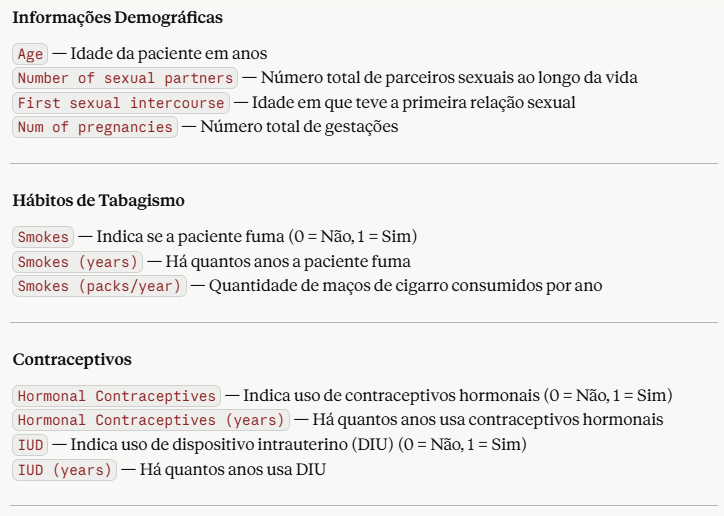

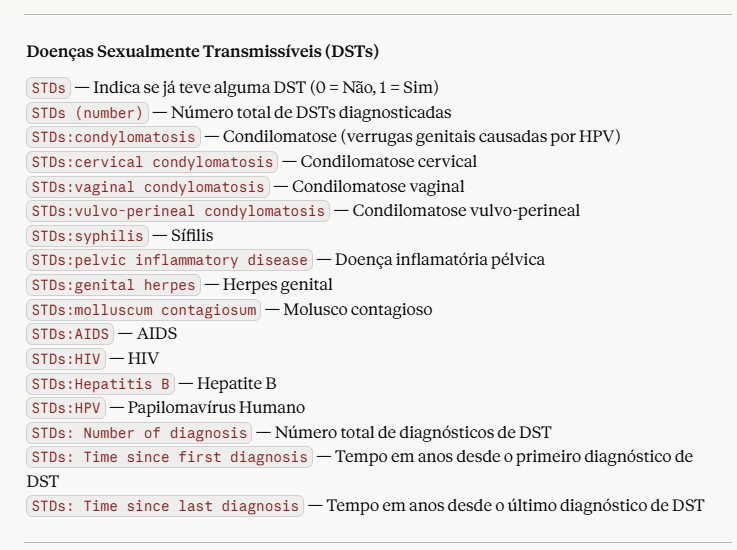



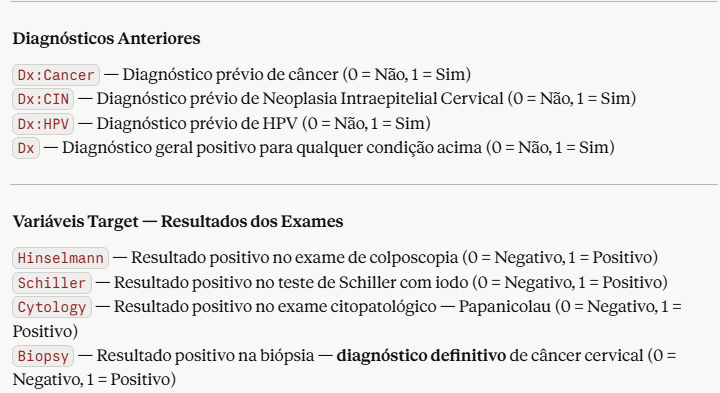


#Configuração do Ambiente e Importação de Bibliotecas

In [181]:
# ── IMPORTAÇÃO DAS BIBLIOTECAS ─────────────────────────────

# Manipulação de dados
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.impute import SimpleImputer

# Arquivos do Google Drive
from google.colab import drive

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns


# Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
# Avaliação
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,f1_score,RocCurveDisplay
from sklearn.metrics import precision_recall_curve


# Algoritmos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, StratifiedKFold

from sklearn.model_selection import cross_val_predict

In [182]:
# ── CARREGAMENTO DO DATASET ─────────────────────────────

# Montagem do drive a partir do google drive
drive.mount('/content/drive')
df_original = pd.read_csv('/content/drive/MyDrive/DATASET 2 - CANCER DE COLO DO UTERO/kag_risk_factors_cervical_cancer.csv')

# Coluna Target
target = 'Biopsy'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Pré-Processamento Inicial

In [183]:
# ── VISUALIZAÇÃO INICIAL ─────────────────────────────
df_original.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [184]:
# ── VERIFICANDO VALORES AUSENTES E TIPOS DE DADOS ─────────────────────────────
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [185]:
# ── VALORES DUPLICADOS ─────────────────────────────

duplicatas = df_original[df_original.duplicated(keep='first')]

if duplicatas.empty:
    print("✅ Nenhum registro duplicado encontrado.")
else:
    print(f"⚠️ {len(duplicatas)} registro(s) duplicado(s) encontrado(s):\n")
    #display(duplicatas)

# Criado sempre, independente de haver duplicatas ou não
df_tratado = df_original.drop_duplicates(keep='first').reset_index(drop=True)

if not duplicatas.empty:
    print(f"\n✅ Duplicatas removidas. O dataset agora possui {len(df_tratado)} registros.")

df_tratado.info()

⚠️ 23 registro(s) duplicado(s) encontrado(s):


✅ Duplicatas removidas. O dataset agora possui 835 registros.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 835 non-null    int64 
 1   Number of sexual partners           835 non-null    object
 2   First sexual intercourse            835 non-null    object
 3   Num of pregnancies                  835 non-null    object
 4   Smokes                              835 non-null    object
 5   Smokes (years)                      835 non-null    object
 6   Smokes (packs/year)                 835 non-null    object
 7   Hormonal Contraceptives             835 non-null    object
 8   Hormonal Contraceptives (years)     835 non-null    object
 9   IUD                                 835 non-null    object
 10  IUD (years) 

In [186]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 835 non-null    int64 
 1   Number of sexual partners           835 non-null    object
 2   First sexual intercourse            835 non-null    object
 3   Num of pregnancies                  835 non-null    object
 4   Smokes                              835 non-null    object
 5   Smokes (years)                      835 non-null    object
 6   Smokes (packs/year)                 835 non-null    object
 7   Hormonal Contraceptives             835 non-null    object
 8   Hormonal Contraceptives (years)     835 non-null    object
 9   IUD                                 835 non-null    object
 10  IUD (years)                         835 non-null    object
 11  STDs                                835 non-null    object

In [187]:
# ── TIPOS DAS COLUNAS E VALORES DO DATASET ─────────────────────────────
pd.DataFrame({
    'Tipo': df_tratado.dtypes,
    'Valores Únicos': df_tratado.nunique(),
    'Exemplos': [sorted(df_tratado[col].dropna().unique())[:5] for col in df_tratado.columns]
    })

,Tipo,Valores Únicos,Exemplos
Age,int64,44,"[13, 14, 15, 16, 17]"
Number of sexual partners,object,13,"[1.0, 10.0, 15.0, 2.0, 28.0]"
First sexual intercourse,object,22,"[10.0, 11.0, 12.0, 13.0, 14.0]"
Num of pregnancies,object,12,"[0.0, 1.0, 10.0, 11.0, 2.0]"
Smokes,object,3,"[0.0, 1.0, ?]"
Smokes (years),object,31,"[0.0, 0.16, 0.5, 1.0, 1.266972909]"
Smokes (packs/year),object,63,"[0.0, 0.001, 0.003, 0.025, 0.04]"
Hormonal Contraceptives,object,3,"[0.0, 1.0, ?]"
Hormonal Contraceptives (years),object,41,"[0.0, 0.08, 0.16, 0.17, 0.25]"
IUD,object,3,"[0.0, 1.0, ?]"


In [188]:
df_tratado.info()
# ── CONVERTENDO TIPOS DE DADOS NÃO NUMERICOS PARA NUMERICOS ─────────────────────────────

# Considerando que a dataset não possui feature categoricas, a logica a seguir vai identificar os valores não
#numéricos em cada coluna e  e tenta converter para numericos

# Garante que df_tratado é independente e não uma view
df_tratado = df_tratado.copy()

encontrou = False
df_tratado_antes = df_tratado.copy()

# 0. Remove espaços e caracteres invisíveis e substitui strings vazias por NaN
for col in df_tratado.select_dtypes(include='object').columns:
    df_tratado.loc[:, col] = df_tratado[col].str.strip()
    df_tratado.loc[:, col] = df_tratado[col].str.replace('\xa0', '', regex=False)
    df_tratado.loc[:, col] = df_tratado[col].str.replace('\t',   '', regex=False)

# 1. Substitui valores não numéricos por NaN e converte todas as colunas para numérico
print('1 - SUBSTITUI VALORES NÃO NUMÉRICOS PARA NaN E CONVERTE PARA NUMÉRICO.')
for col in df_tratado.columns:
    mascara = pd.to_numeric(df_tratado[col], errors='coerce').isna() & df_tratado[col].notna()

    if mascara.sum() > 0:
        encontrou = True
        valores_antes = df_tratado_antes[col][mascara].unique()

        df_tratado[col] = pd.to_numeric(df_tratado[col], errors='coerce')

        print(f"Coluna             : {col} — Tipo Original: {df_tratado_antes[col].dtype}")
        print(f"Tipo Após Conversão: {df_tratado[col].dtype}")
        print(f"Total Não Numéricos: {mascara.sum()} registros ({mascara.sum() / len(df_tratado) * 100:.1f}%)")
        for antes in valores_antes:
            print(f"  Substituição     : '{antes}' → NaN")
        print()

    # Converte para numérico mesmo que não tenha valores não numéricos
    elif df_tratado[col].dtype == 'object':
        df_tratado[col] = pd.to_numeric(df_tratado[col], errors='coerce')
        print(f"Coluna             : {col} — Tipo Original: {df_tratado_antes[col].dtype}")
        print(f"Tipo Após Conversão: {df_tratado[col].dtype}")
        print(f"Total Não Numéricos: 0 registros (0.0%)")
        print()

if not encontrou:
    print("✅ Nenhum valor não numérico encontrado.\n")

# 2. Resumo final
colunas_object = df_tratado.select_dtypes(include='object').columns
if len(colunas_object) == 0:
    print("✅ Todas as colunas foram convertidas para tipo numérico.")
else:
    print(f"⚠️ {len(colunas_object)} coluna(s) ainda como object: {list(colunas_object)}")
df_tratado.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 835 non-null    int64 
 1   Number of sexual partners           835 non-null    object
 2   First sexual intercourse            835 non-null    object
 3   Num of pregnancies                  835 non-null    object
 4   Smokes                              835 non-null    object
 5   Smokes (years)                      835 non-null    object
 6   Smokes (packs/year)                 835 non-null    object
 7   Hormonal Contraceptives             835 non-null    object
 8   Hormonal Contraceptives (years)     835 non-null    object
 9   IUD                                 835 non-null    object
 10  IUD (years)                         835 non-null    object
 11  STDs                                835 non-null    object

In [189]:
# ── TIPOS DAS COLUNAS E VALORES DO DATASET ─────────────────────────────
pd.DataFrame({
    'Tipo': df_tratado.dtypes,
    'Valores Únicos': df_tratado.nunique(),
    'Exemplos': [sorted(df_tratado[col].dropna().unique())[:5] for col in df_tratado.columns]
    })

,Tipo,Valores Únicos,Exemplos
Age,int64,44,"[13, 14, 15, 16, 17]"
Number of sexual partners,float64,12,"[1.0, 2.0, 3.0, 4.0, 5.0]"
First sexual intercourse,float64,21,"[10.0, 11.0, 12.0, 13.0, 14.0]"
Num of pregnancies,float64,11,"[0.0, 1.0, 2.0, 3.0, 4.0]"
Smokes,float64,2,"[0.0, 1.0]"
Smokes (years),float64,30,"[0.0, 0.16, 0.5, 1.0, 1.266972909]"
Smokes (packs/year),float64,62,"[0.0, 0.001, 0.003, 0.025, 0.04]"
Hormonal Contraceptives,float64,2,"[0.0, 1.0]"
Hormonal Contraceptives (years),float64,40,"[0.0, 0.08, 0.16, 0.17, 0.25]"
IUD,float64,2,"[0.0, 1.0]"


In [190]:

df_tratado.info()
# ── 1. Definir as colunas a remover ──────────────────────────────────────────

colunas_remover = [
    'STDs: Time since first diagnosis', # Coluna removida por "NaN" representar 91.7% dos registros com ?
    'STDs: Time since last diagnosis', # Coluna removida por "NaN" representar 91.7% dos registros com ?
    'STDs:cervical condylomatosis', # Apenas valores zerados ou "NaN". Após a imputação vão ficar todos zerados
    'STDs:AIDS' # Apenas valores zerados ou "Nan". Após a imputação vão ficar todos zerados"
]


# ── 2. Verificar se as colunas existem no dataframe ──────────────────────────
colunas_validas   = [col for col in colunas_remover if col in df_tratado.columns]
colunas_invalidas = [col for col in colunas_remover if col not in df_tratado.columns]

if colunas_invalidas:
    print(f"⚠ Colunas não encontradas no dataframe: {colunas_invalidas}")

# ── 3. Remover as colunas ─────────────────────────────────────────────────────
if colunas_validas:
    df_tratado = df_tratado.drop(columns=colunas_validas)
    print(f"✔ Colunas removidas com sucesso!")
    print(f"  Colunas antes : {len(df_tratado.columns) + len(colunas_validas)}")
    print(f"  Colunas depois: {len(df_tratado.columns)}")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

In [191]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

# Análise Exploratória dos Dados (EDA)

In [192]:
# =============================================================================
# Apresentando as estatisticas de cada coluna
# =============================================================================

df_tratado.describe()
# Valores mínimos e máximos válidos

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,835.000000,810.000000,828.000000,779.000000,822.000000,822.000000,822.000000,732.000000,732.000000,723.000000,...,735.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,27.023952,2.551852,17.020531,2.304236,0.149635,1.253850,0.465823,0.651639,2.302916,0.114799,...,0.002721,0.089820,0.021557,0.010778,0.021557,0.028743,0.041916,0.087425,0.051497,0.064671
std,8.482986,1.676686,2.817000,1.455817,0.356930,4.140727,2.256273,0.476777,3.794180,0.319000,...,0.052129,0.306335,0.145319,0.103320,0.145319,0.167182,0.200518,0.282626,0.221142,0.246091
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [193]:
# =============================================================================
# Apresentando balanceamento da variável alvo
# =============================================================================
print(f"\n### Balanceamento da Variável Alvo ({target}) ###")
balanceamento = df_tratado[target].value_counts()
percentual    = df_tratado[target].value_counts(normalize=True) * 100

print(f"Sem câncer (0): {balanceamento[0]} registros ({percentual[0]:.1f}%)")
print(f"Com câncer (1): {balanceamento[1]} registros ({percentual[1]:.1f}%)")
df_tratado.info()


### Balanceamento da Variável Alvo (Biopsy) ###
Sem câncer (0): 781 registros (93.5%)
Com câncer (1): 54 registros (6.5%)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    

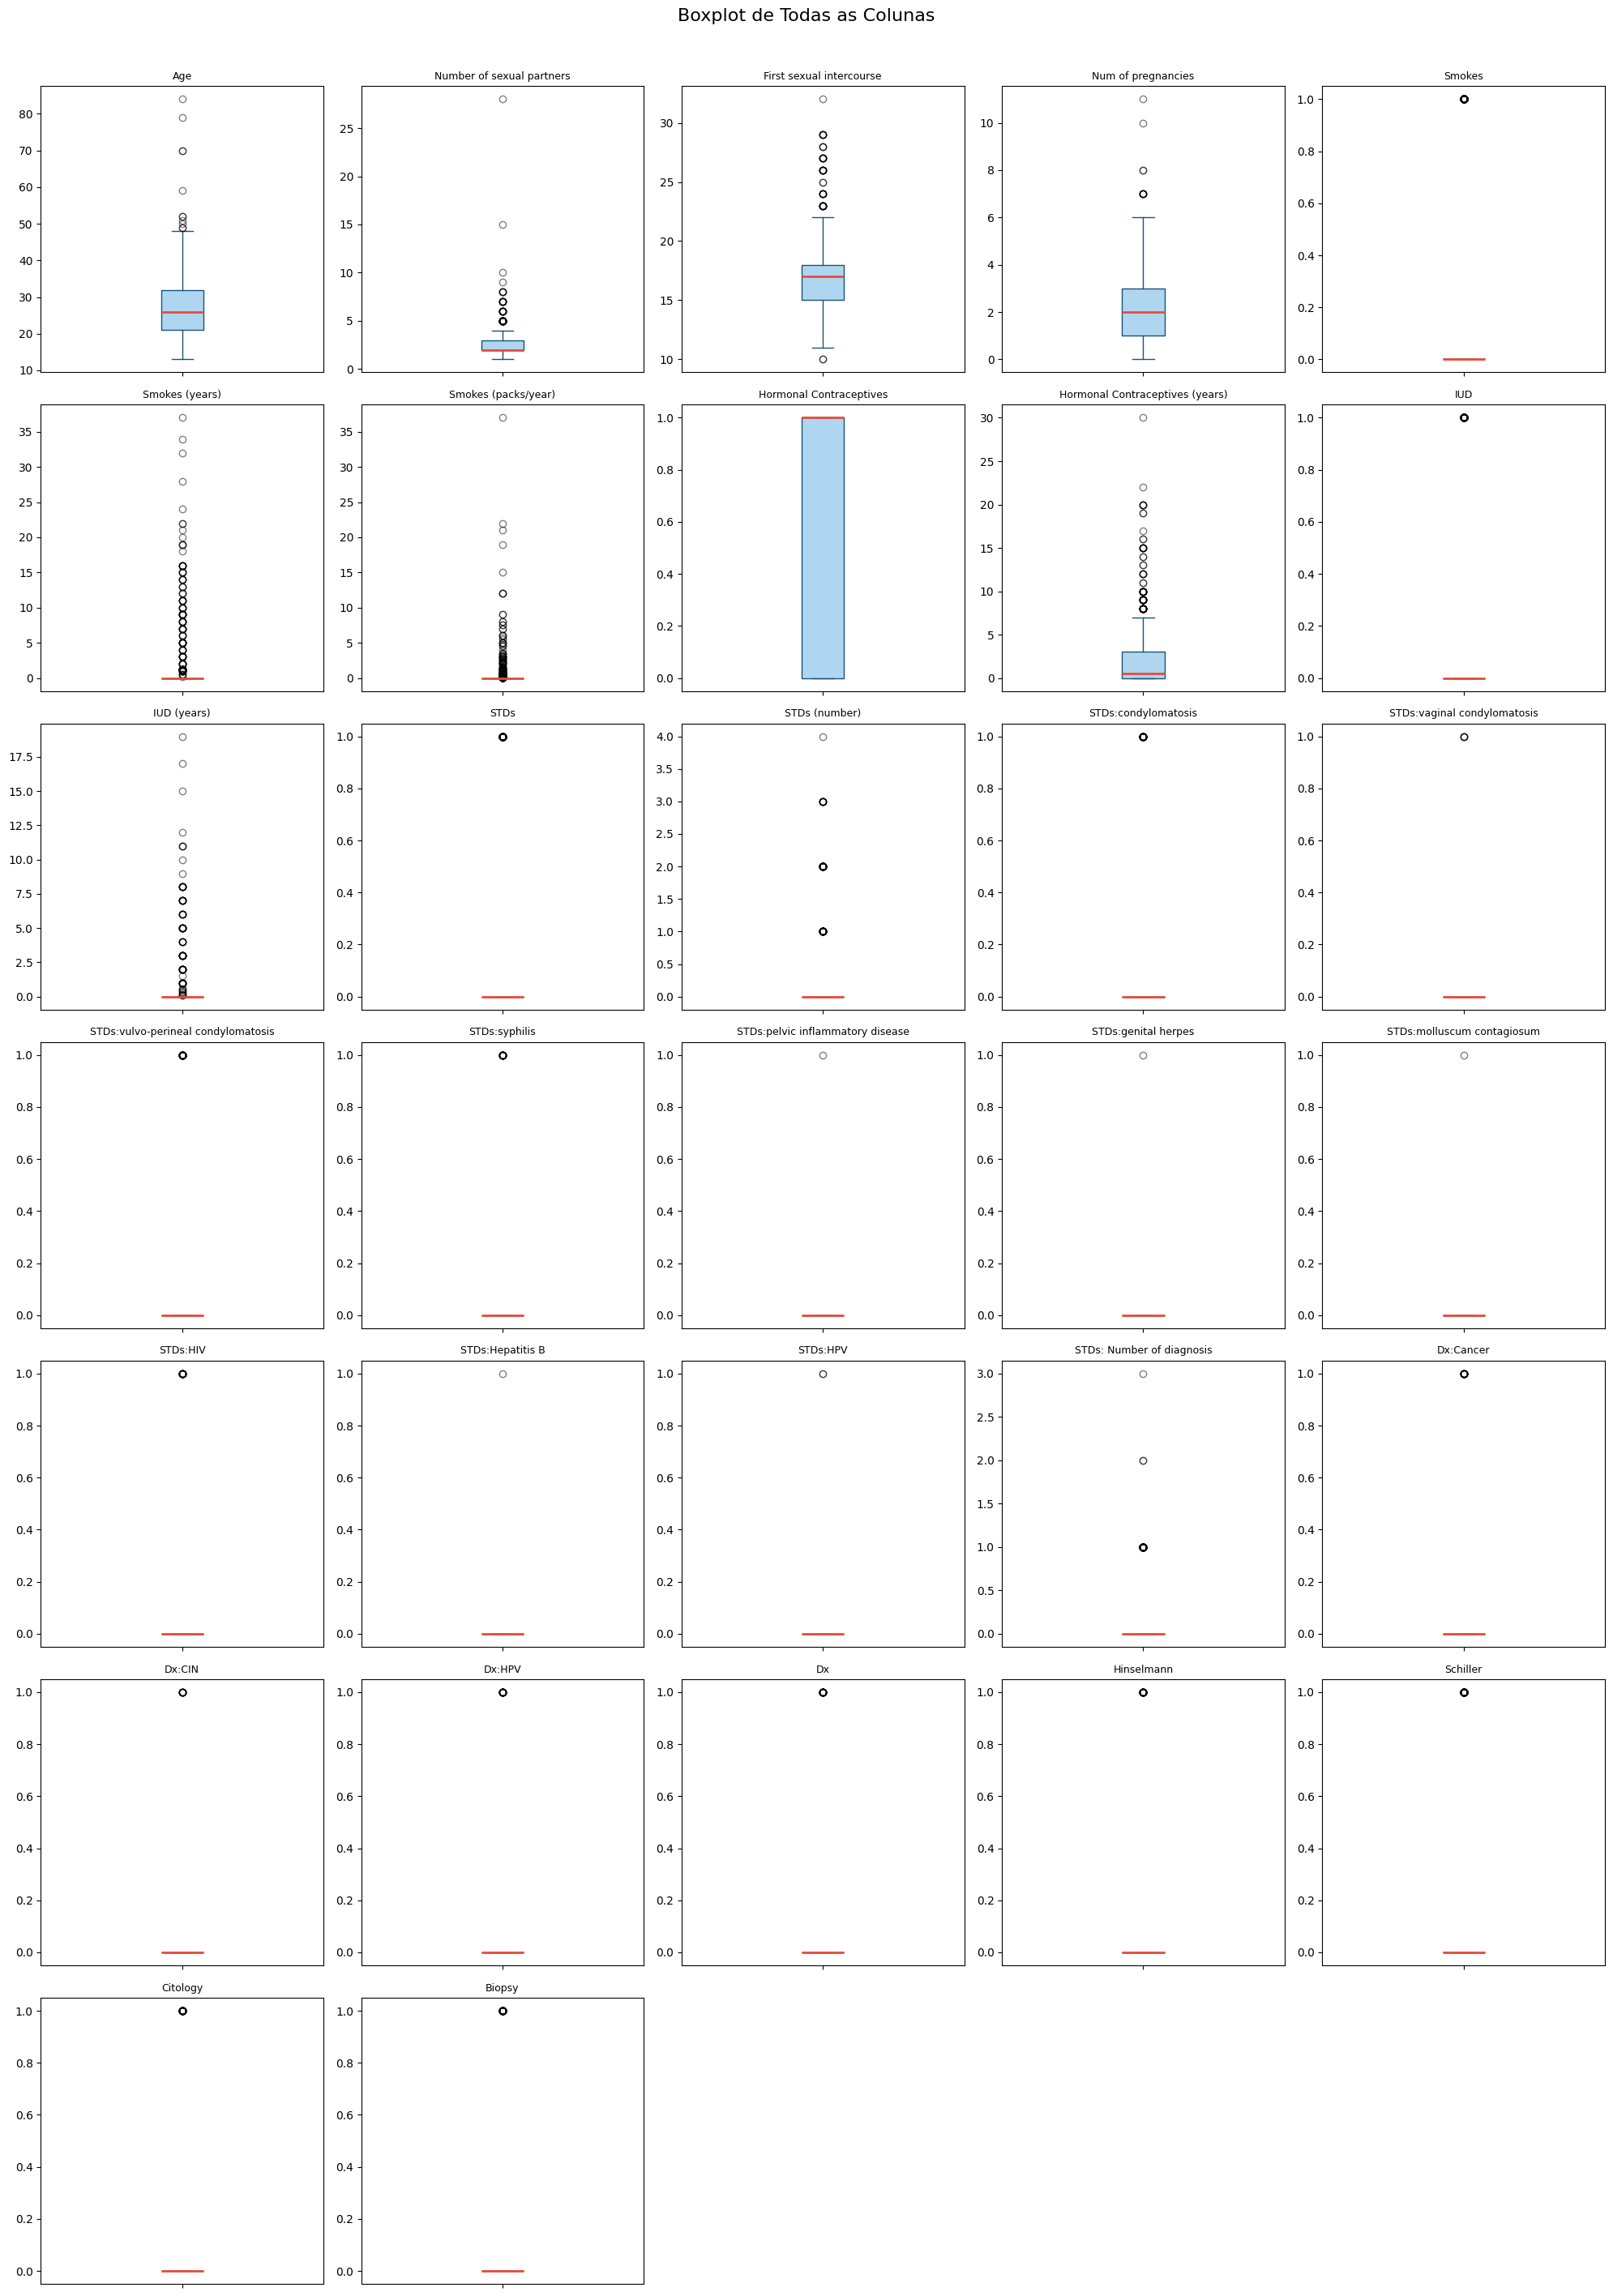

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

In [194]:
# ================================================================
# Análise do Bloxpot de cada coluna
# ================================================================

#seleciona apenas as colunas numéricas
numeric_df = df_tratado.select_dtypes(include="number")

n_cols = 5
n_rows = -(-len(numeric_df.columns) // n_cols)  # arredonda para cima

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    axes[i].boxplot(numeric_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#AED6F1", color="#1A5276"),
                    medianprops=dict(color="#E74C3C", linewidth=2),
                    whiskerprops=dict(color="#1A5276"),
                    capprops=dict(color="#1A5276"),
                    flierprops=dict(marker="o", color="#E74C3C", alpha=0.5))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="x", labelbottom=False)

for j in range(i + 1, len(axes)):  # oculta subplots vazios
    axes[j].set_visible(False)

fig.suptitle("Boxplot de Todas as Colunas", fontsize=16, y=1.01)
plt.tight_layout()
#plt.savefig("boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Boxplots salvos em: boxplots.png")

df_tratado.info()


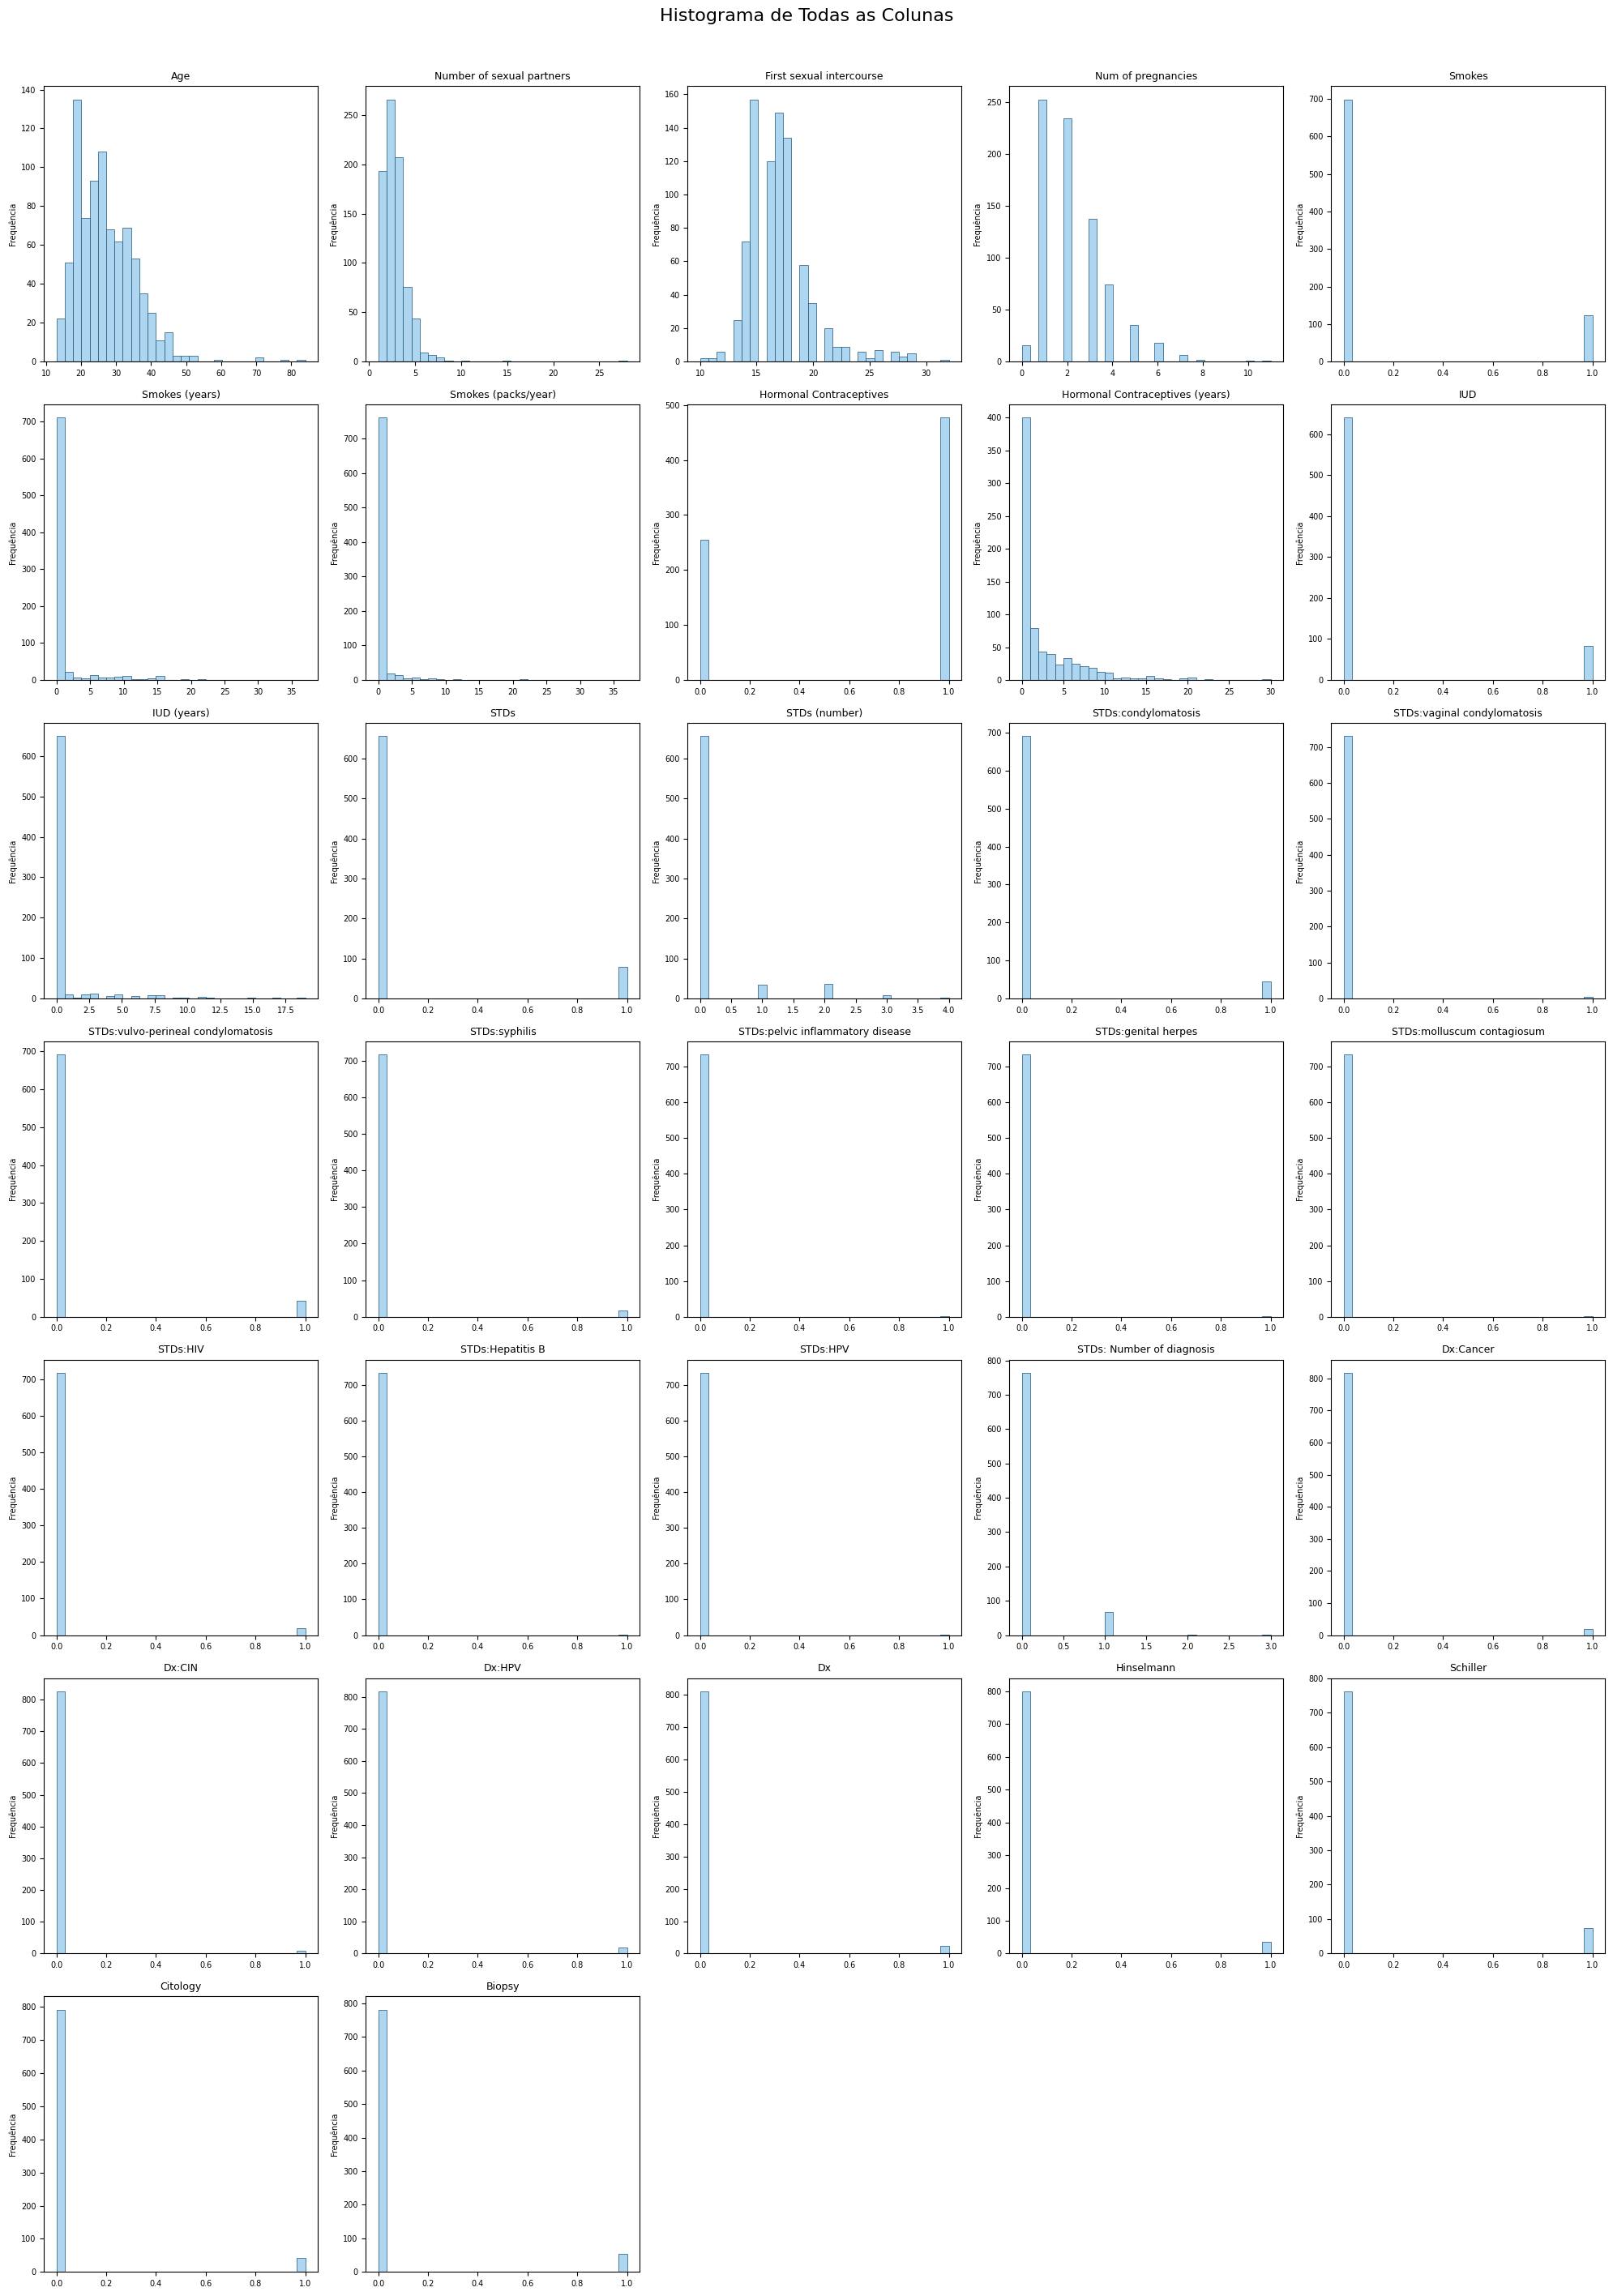

Histogramas salvos em: histogramas.png


In [195]:
# ================================================================
# Análise do histograma de cada coluna
# ================================================================


# ── 2. HISTOGRAMAS ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    axes[i].hist(numeric_df[col].dropna(), bins=30,
                 color="#AED6F1", edgecolor="#1A5276", linewidth=0.5)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("Frequência", fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):  # oculta subplots vazios
    axes[j].set_visible(False)

fig.suptitle("Histograma de Todas as Colunas", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("histogramas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Histogramas salvos em: histogramas.png")

# Pré-Processamento Refinado e Feature Engineering

In [196]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

In [197]:
#PRE PROCESSAMENTO

# INPUTANDO VALORES PARA SUBSTITUIR "NaN"


colunas_binarias = [
  "Hormonal Contraceptives",
  "IUD",
  "Smokes",
  "Dx:Cancer",
  "Dx:CIN",
  "Dx:HPV",
  "Dx",
  "STDs",
  "STDs:condylomatosis",
  "STDs:vulvo-perineal condylomatosis",
  "STDs:vaginal condylomatosis",
  "STDs:pelvic inflammatory disease",
  "STDs:syphilis",
  "STDs:genital herpes",
  "STDs:molluscum contagiosum",
  "STDs:HIV",
  "STDs:Hepatitis B",
  "STDs:HPV",
  "Hinselmann",
  "Schiller",
  "Cytology",

]

colunas_numericas = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Hormonal Contraceptives (years)",
    "Smokes (years)",
    "Smokes (packs/year)",
    "IUD (years)",
    "STDs (number)",
    "STDs: Number of diagnosis",
]


# ── Correção: converter todas as colunas para numérico antes de imputar ──────
for col in colunas_binarias + colunas_numericas:
    if col in df_tratado.columns:
        df_tratado[col] = pd.to_numeric(df_tratado[col], errors='coerce')

# ── 1. Imputar colunas binárias — estratégia: MODA ───────────────────────────
imputer_bin = SimpleImputer(strategy='most_frequent')

print(f"\n{'='*60}")
print(f"  Colunas Binárias — Imputação pela MODA")
print(f"{'='*60}")

for col in colunas_binarias:
    if col in df_tratado.columns:
        n_ausentes = df_tratado[col].isnull().sum()
        if n_ausentes > 0:
            moda = df_tratado[col].mode()[0]
            print(f"\n  Coluna  : {col}")
            print(f"  Moda    : {moda}")
            print(f"  Ausentes: {n_ausentes} registros")
            df_tratado[col] = imputer_bin.fit_transform(df_tratado[[col]]).ravel()

# ── 2. Imputar colunas numéricas — estratégia: MEDIANA ───────────────────────
imputer_num = SimpleImputer(strategy='median')

print(f"\n{'='*60}")
print(f"  Colunas Numéricas — Imputação pela MEDIANA")
print(f"{'='*60}")

for col in colunas_numericas:
    if col in df_tratado.columns:
        n_ausentes = df_tratado[col].isnull().sum()
        if n_ausentes > 0:
            mediana = df_tratado[col].median()
            print(f"\n  Coluna  : {col}")
            print(f"  Mediana : {mediana}")
            print(f"  Ausentes: {n_ausentes} registros")
            df_tratado[col] = imputer_num.fit_transform(df_tratado[[col]]).ravel()

# ── 3. Verificar se ainda há ausentes ────────────────────────────────────────
ausentes_restantes = df_tratado.isnull().sum().sum()
print(f"\n{'='*60}")
print(f"  RESUMO FINAL")
print(f"{'='*60}")
print(f"  Valores ausentes restantes: {ausentes_restantes}")
if ausentes_restantes == 0:
    print("  ✔ Todos os valores ausentes foram imputados!")
else:
    print("  ⚠ Ainda há valores ausentes:")
    print(df_tratado.isnull().sum()[df_tratado.isnull().sum() > 0])

df_tratado.info()


  Colunas Binárias — Imputação pela MODA

  Coluna  : Hormonal Contraceptives
  Moda    : 1.0
  Ausentes: 103 registros

  Coluna  : IUD
  Moda    : 0.0
  Ausentes: 112 registros

  Coluna  : Smokes
  Moda    : 0.0
  Ausentes: 13 registros

  Coluna  : STDs
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:condylomatosis
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:vulvo-perineal condylomatosis
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:vaginal condylomatosis
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:pelvic inflammatory disease
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:syphilis
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:genital herpes
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:molluscum contagiosum
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:HIV
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:Hepatitis B
  Moda    : 0.0
  Ausentes: 100 registros



## TRATANDO OUTLIERS

In [198]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           835 non-null    float64
 2   First sexual intercourse            835 non-null    float64
 3   Num of pregnancies                  835 non-null    float64
 4   Smokes                              835 non-null    float64
 5   Smokes (years)                      835 non-null    float64
 6   Smokes (packs/year)                 835 non-null    float64
 7   Hormonal Contraceptives             835 non-null    float64
 8   Hormonal Contraceptives (years)     835 non-null    float64
 9   IUD                                 835 non-null    float64
 10  IUD (years)                         835 non-null    float64
 11  STDs                                835 non-n

In [199]:
# Identificando Outliers

numeric_df = df_tratado.select_dtypes(include="number")

Q1  = numeric_df.quantile(0.25)
Q3  = numeric_df.quantile(0.75)
IQR = Q3 - Q1

resultados = []

for col in numeric_df.columns:
    limite_inferior = Q1[col] - 1.5 * IQR[col]  # ← limites calculados por coluna
    limite_superior = Q3[col] + 1.5 * IQR[col]

    # IQR
    n_iqr = ((numeric_df[col] < limite_inferior) |
             (numeric_df[col] > limite_superior)).sum()

    # Z-Score
    n_z = (abs(stats.zscore(numeric_df[col].dropna())) > 3).sum()

    resultados.append({
        'Coluna'          : col,
        'Lim. Inferior'   : round(limite_inferior, 4),  # ← novo
        'Lim. Superior'   : round(limite_superior, 4),  # ← novo
        'Outliers IQR'    : n_iqr,
        '% IQR'           : round(n_iqr / len(df_tratado) * 100, 1),
        'Outliers Z'      : n_z,
        '% Z-Score'       : round(n_z / len(df_tratado) * 100, 1)
    })

df_outliers = pd.DataFrame(resultados).sort_values('Outliers IQR', ascending=False)
print(df_outliers.to_string(index=False))

                            Coluna  Lim. Inferior  Lim. Superior  Outliers IQR  % IQR  Outliers Z  % Z-Score
                    Smokes (years)            0.0            0.0           123   14.7          27        3.2
               Smokes (packs/year)            0.0            0.0           123   14.7          14        1.7
                            Smokes            0.0            0.0           123   14.7           0        0.0
                               IUD            0.0            0.0            83    9.9          83        9.9
                       IUD (years)            0.0            0.0            83    9.9          28        3.4
                              STDs            0.0            0.0            79    9.5          79        9.5
                     STDs (number)            0.0            0.0            79    9.5          45        5.4
                          Schiller            0.0            0.0            73    8.7          73        8.7
         STDs: Numb

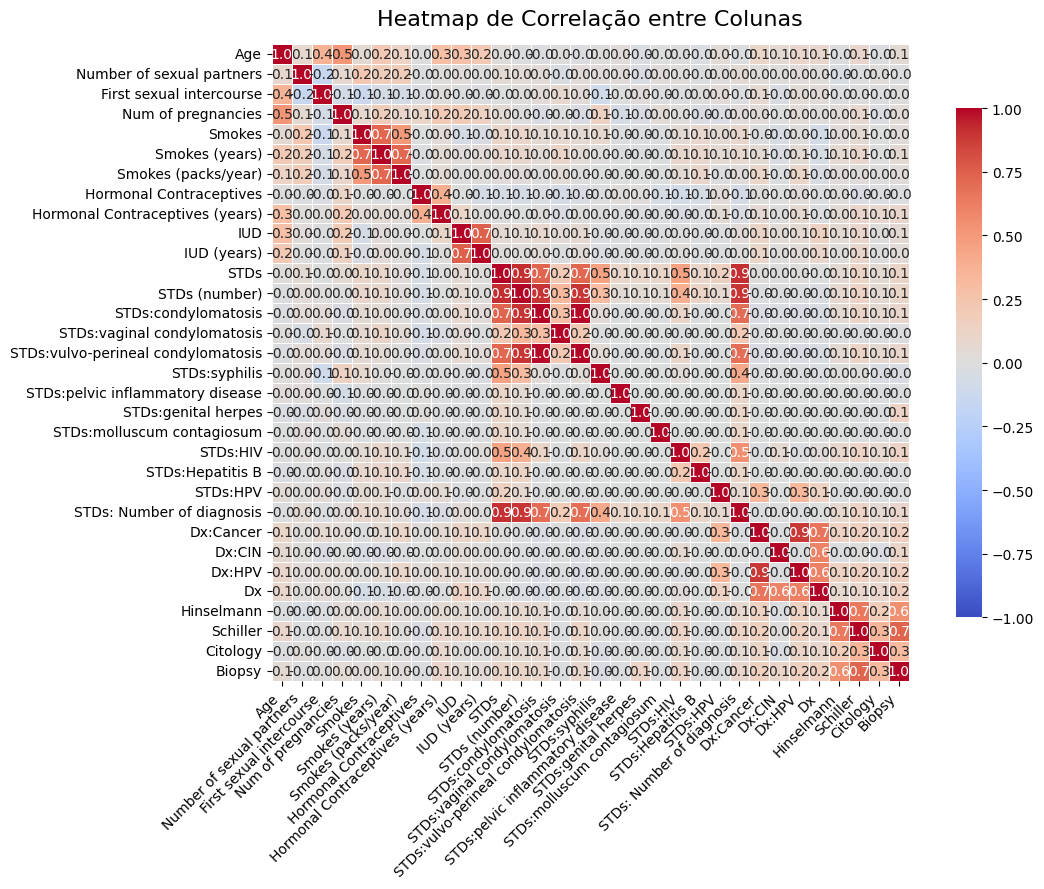

<Figure size 2400x2000 with 0 Axes>

Heatmap salvo em: heatmap_correlacao.png


In [200]:

# ================================================================
# Análise do correlacionamento entre as colunas - Mapa de calor
# ================================================================

# ── 1. Seleciona apenas colunas numéricas ────────────────────────────────────
numeric_df = df_tratado.select_dtypes(include="number")

# ── 2. Calcula a matriz de correlação ────────────────────────────────────────
corr = numeric_df.corr()

# ── 3. Plota o heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(12, 9))

# Definindo um threshold para apresentar no mapa apenas as colunas fortemente correlacionadas
#threshold = 0.7
#mask = corr.abs() < threshold  # oculta correlações fracas

sns.heatmap(
    corr,
    annot=True,          # exibe os valores dentro das células
    fmt=".1f",           # 1 casa decimal
 #   mask=mask,           # Define o threshold
    cmap="coolwarm",     # paleta divergente: azul (negativo) → vermelho (positivo)
    vmin=-1, vmax=1,     # escala fixa de correlação
    linewidths=0.5,      # grade entre as células
    square=True,         # células quadradas
    cbar_kws={"shrink": 0.8},
)

plt.title("Heatmap de Correlação entre Colunas", fontsize=16, pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.figure(figsize=(24, 20))
plt.savefig("heatmap_correlacao.png", dpi=150)
plt.show()
print("Heatmap salvo em: heatmap_correlacao.png")

#6. Divisão dos Dados — Treino e Teste


In [201]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           835 non-null    float64
 2   First sexual intercourse            835 non-null    float64
 3   Num of pregnancies                  835 non-null    float64
 4   Smokes                              835 non-null    float64
 5   Smokes (years)                      835 non-null    float64
 6   Smokes (packs/year)                 835 non-null    float64
 7   Hormonal Contraceptives             835 non-null    float64
 8   Hormonal Contraceptives (years)     835 non-null    float64
 9   IUD                                 835 non-null    float64
 10  IUD (years)                         835 non-null    float64
 11  STDs                                835 non-n

In [202]:

# Separando features e target
X = df_tratado.drop(columns=[target])
y = df_tratado[target]
#y = y.map({1: 0, 2: 1}) # Coluna target com valores 1 e 2. Alterado para 0 e 1 para funcionar o XGBoost

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,        # 80% treino | 20% teste
    stratify=y,           # mantém proporção dos valores da coluna target
    random_state=42)

print(f"Treino : {X_train.shape[0]} registros")
print(f"Teste  : {X_test.shape[0]} registros")

Treino : 584 registros
Teste  : 251 registros


#7. Treinamento dos Modelos

In [203]:
# Aplicando o StandardScaler para padronizar a escala das features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [204]:
# Regressão Logística
#lr = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)
#lr.fit(X_train_scaled, y_train) # usando as colunas com escala padronizadas


lr = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    solver='saga',        # melhor para datasets desbalanceados
    penalty='elasticnet', # combina L1 + L2, mais robusto que apenas 'l2'
    l1_ratio=0.5,         # proporção L1/L2 — pode variar entre 0 e 1
    C=0.1                 # mais regularização (padrão é 1.0) — reduz falsos positivos
)

# Ou via GridSearch para encontrar o melhor C e l1_ratio:
params = {
    'C': [0.01, 0.1, 0.5, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
grid_lr = GridSearchCV(lr, params, scoring='f1', cv=5)
grid_lr.fit(X_train_scaled, y_train)




/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=5,
             estimator=LogisticRegression(C=0.1, class_weight='balanced',
                                          l1_ratio=0.5, max_iter=5000,
                                          penalty='elasticnet', random_state=42,
                                          solver='saga'),
             param_grid={'C': [0.01, 0.1, 0.5, 1.0],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='f1')

In [205]:
# Randon Forest

#rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
#rf.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(
    n_estimators=500,          # mais árvores = mais estabilidade (era 100)
    class_weight='balanced_subsample',  # mais eficaz que 'balanced' para RF
    max_depth=10,              # limita overfitting
    min_samples_leaf=2,        # evita folhas com 1 amostra
    min_samples_split=5,
    max_features='sqrt',       # padrão, mas vale deixar explícito
    n_jobs=-1,
    random_state=42
)

# Ou GridSearch focando em recall:
params = {
    'n_estimators': [200, 500],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}
grid_rf = GridSearchCV(rf, params, scoring='recall', cv=5)
grid_rf.fit(X_train_scaled, y_train)



GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                              max_depth=10, min_samples_leaf=2,
                                              min_samples_split=5,
                                              n_estimators=500, n_jobs=-1,
                                              random_state=42),
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'max_depth': [5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [200, 500]},
             scoring='recall')

In [206]:
# XGBClassifier
#xgb = XGBClassifier(scale_pos_weight=65/35, random_state=42, eval_metric='logloss')
#xgb.fit(X_train_scaled, y_train)

# Calcule o peso correto com base no seu y_train real
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos  # ex: ~14.0 para 93.4% / 6.6%

xgb = XGBClassifier(
    scale_pos_weight=scale,   # valor calculado dinamicamente
    n_estimators=300,
    learning_rate=0.05,       # menor = mais conservador (era padrão 0.3)
    max_depth=4,              # era padrão 6 — reduz overfitting
    subsample=0.8,            # amostragem por árvore
    colsample_bytree=0.8,     # amostragem de features por árvore
    min_child_weight=5,       # exige mais amostras por folha — ajuda no desbalanceamento
    random_state=42,
    eval_metric='aucpr'       # AUC-PR é mais informativa que logloss em dados desbalanceados
)

xgb.fit(X_train_scaled, y_train)  # ✅ treina o modelo

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [207]:
# KNN
#knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
#knn.fit(X_train_scaled, y_train)

# Ajuste 1: buscar o melhor K com scoring em recall
params = {'n_neighbors': [3, 5, 7, 11, 15, 21]}
grid_knn = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    params,
    scoring='recall',  # prioriza detectar os positivos
    cv=5
)
grid_knn.fit(X_train_scaled, y_train)

# Ajuste 2: usar distância ponderada (vizinhos mais próximos têm mais peso)
knn = KNeighborsClassifier(
    n_neighbors=grid_knn.best_params_['n_neighbors'],
    weights='distance',  # era padrão 'uniform'
    metric='manhattan',  # testar também 'euclidean' e 'minkowski'
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)  # ✅ adicione esta linha

KNeighborsClassifier(metric='manhattan', n_jobs=-1, n_neighbors=3,
                     weights='distance')

In [208]:
# SVM
#svm = SVC(class_weight='balanced', kernel='rbf', probability=True, random_state=42)
#svm.fit(X_train_scaled, y_train)
svm = SVC(
    class_weight='balanced',
    kernel='rbf',
    probability=True,
    random_state=42,
    C=10,        # aumentar C = menos margem, mais acertos nos positivos
    gamma='scale'  # deixar explícito
)

svm.fit(X_train_scaled, y_train)

# ✅ Calcular threshold no conjunto de TREINO com cross_val_predict
from sklearn.model_selection import cross_val_predict

probs_train = cross_val_predict(
    svm, X_train_scaled, y_train,
    cv=5,
    method='predict_proba'
)[:, 1]

# Otimizar threshold nos dados de treino
precisoes, recalls, thresholds = precision_recall_curve(y_train, probs_train)
f1_scores = 2 * (precisoes * recalls) / (precisoes + recalls + 1e-9)
melhor_threshold = thresholds[np.argmax(f1_scores)]

print(f"Melhor threshold encontrado no treino: {melhor_threshold:.4f}")

# ✅ Aplicar no teste — agora sim uma avaliação honesta
probs_test = svm.predict_proba(X_test_scaled)[:, 1]
y_pred_ajustado = (probs_test >= melhor_threshold).astype(int)


Melhor threshold encontrado no treino: 0.1484


#8. Avaliação dos Modelos

##Metrica mais importante para essa trabalho é RECALL. Dica da Professora Medica.

*   Com Câncer    0.73   ← Sensibilidade
*   Sem Câncer    0.80   ← Especificidade

## Valores mínimos esperados

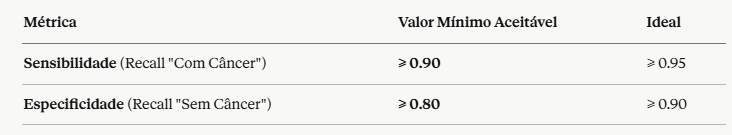




In [209]:


# ================================================
# Curva ROC — Todos os Modelos
# ================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Regressão Logística' : grid_lr.best_estimator_,
    'Random Forest'       : grid_rf.best_estimator_,
    'XGBoost'             : xgb,
    'KNN'                 : knn,
    'SVM'                 : svm
}


resultados = []

for nome, modelo in modelos.items():


    scores = cross_validate(
        modelo, X_train_scaled, y_train,
        cv=cv,
        scoring=['f1', 'roc_auc'],
        return_train_score=False
    )
    f1_cv  = scores['test_f1'].mean()
    auc_cv = scores['test_roc_auc'].mean()
    f1_std  = scores['test_f1'].std()
    auc_std = scores['test_roc_auc'].std()

    # ── Avaliação no Test Set ─────────────────────────────────────────────────
    y_pred      = modelo.predict(X_test_scaled)
    y_pred_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    f1_test     = f1_score(y_test, y_pred)
    auc_test    = roc_auc_score(y_test, y_pred_prob)

    resultados.append({
        'Modelo'        : nome,
        'F1 CV'         : round(f1_cv, 4),
        'F1 CV Std'     : round(f1_std, 4),
        'AUC CV'        : round(auc_cv, 4),
        'AUC CV Std'    : round(auc_std, 4),
        'F1 Teste'      : round(f1_test, 4),
        'AUC Teste'     : round(auc_test, 4)
    })




    print(f"\n{'='*50}")
    print(f"  {nome}")
    print(f"{'='*50}")
    print(f"  F1  CV   : {f1_cv:.4f} ± {f1_std:.4f}")
    print(f"  AUC CV   : {auc_cv:.4f} ± {auc_std:.4f}")
    print(f"  F1  Test : {f1_test:.4f}")
    print(f"  AUC Test : {auc_test:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Sem Câncer', 'Com Câncer'])}")

df_resultados = pd.DataFrame(resultados).sort_values('AUC CV', ascending=False)
print("\n### Comparativo Final dos Modelos ###")
print(df_resultados.to_string(index=False))




/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



  Regressão Logística
  F1  CV   : 0.7508 ± 0.0949
  AUC CV   : 0.9459 ± 0.0549
  F1  Test : 0.7179
  AUC Test : 0.9219

              precision    recall  f1-score   support

  Sem Câncer       0.99      0.96      0.98       235
  Com Câncer       0.61      0.88      0.72        16

    accuracy                           0.96       251
   macro avg       0.80      0.92      0.85       251
weighted avg       0.97      0.96      0.96       251


  Random Forest
  F1  CV   : 0.7508 ± 0.0949
  AUC CV   : 0.9748 ± 0.0248
  F1  Test : 0.7000
  AUC Test : 0.9239

              precision    recall  f1-score   support

  Sem Câncer       0.99      0.96      0.97       235
  Com Câncer       0.58      0.88      0.70        16

    accuracy                           0.95       251
   macro avg       0.79      0.92      0.84       251
weighted avg       0.97      0.95      0.96       251


  XGBoost
  F1  CV   : 0.7270 ± 0.0955
  AUC CV   : 0.9765 ± 0.0214
  F1  Test : 0.7179
  AUC Test : 0.9186

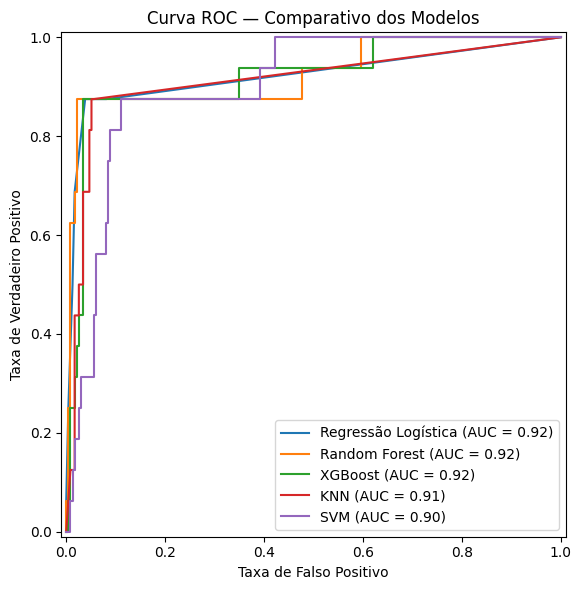

In [210]:
# ================================================
# Curva ROC — Todos os Modelos
# ================================================

fig, ax = plt.subplots(figsize=(8, 6))

for nome, modelo in modelos.items():
    RocCurveDisplay.from_estimator(modelo, X_test_scaled, y_test, ax=ax, name=nome)

ax.set_title('Curva ROC — Comparativo dos Modelos')
ax.set_xlabel('Taxa de Falso Positivo')
ax.set_ylabel('Taxa de Verdadeiro Positivo')
plt.tight_layout()
plt.show()

#9. Conclusão